# Comparing classifiers (including Bayesian networks) with scikit-learn

In this notebook, we use the skbn module to insert bayesian networks into some examples from the scikit-learn documentation (that we refer).

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F53-Classifier_CompareClassifiersWithSklearn.ipynb)

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from pyagrum.skbn import BNClassifier, createBNClassifier

## Binary classifiers

In [2]:
# From https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)
# Code source: Gael Varoquaux Andreas Muller
# Modified for documentation by Jaques Grobler
# License: BSD 3 clause

In [3]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [4]:
# the data
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
  make_moons(noise=0.3, random_state=0),
  make_circles(noise=0.2, factor=0.5, random_state=1),
  linearly_separable,
]
datasets_name = ["Moons ", "Circle", "LinSep"]

In [5]:
from ipywidgets import IntProgress


def showComparison(names, classifiers, datasets, datasets_name):  # the results
  bnres = [None] * len(datasets_name)
  h = 0.02  # step size in the mesh
  fs = 6

  figure = plt.figure(figsize=(12, 4))
  i = 1
  # iterate over datasets
  for ds_cnt, ds in enumerate(datasets):
    print(datasets_name[ds_cnt] + " : ", end="")
    # preprocess dataset, split into training and test part
    X, y = ds
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
      ax.set_title("Input data", fontsize=fs)
    ax.set_ylabel(datasets_name[ds_cnt])

    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k", marker=".")
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k", marker=".")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    f = IntProgress(min=0, max=len(names))
    display(f)
    for name, clf in zip(names, classifiers):
      # print(".", end="", flush=True)
      f.value += 1
      ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
      clf.fit(X_train, y_train)
      score = clf.score(X_test, y_test)

      # Plot the decision boundary. For that, we will assign a color to each
      # point in the mesh [x_min, x_max]x[y_min, y_max].
      if hasattr(clf, "decision_function"):
        Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
      else:
        Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

      # Put the result into a color plot
      Z = Z.reshape(xx.shape)
      ax.contourf(xx, yy, Z, cmap=cm, alpha=0.7)

      # Plot the training points
      # ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
      #           edgecolors='k', alpha=0.2,marker='.')
      # Plot the testing points
      ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, edgecolors="k", marker=".")

      ax.set_xlim(xx.min(), xx.max())
      ax.set_ylim(yy.min(), yy.max())
      ax.set_xticks(())
      ax.set_yticks(())
      if ds_cnt == 0:
        ax.set_title(name, fontsize=fs)
      ax.text(
        xx.max() - 0.3,
        yy.min() + 0.3,
        ("%.2f" % score).lstrip("0"),
        size=12,
        horizontalalignment="right",
        color="white",
        path_effects=[pe.withStroke(linewidth=2, foreground="black")],
      )
      i += 1
    bnres[ds_cnt] = gum.BayesNet(classifiers[-1].bn_)
    print()

  plt.tight_layout()
  plt.show()

  return bnres

In [6]:
# the classifiers
names = [
  "Nearest Neighbors",
  "Linear SVM",
  "RBF SVM",
  "Gaussian Process",
  "Decision Tree",
  "Random Forest",
  "Neural Net",
  "AdaBoost",
  "Naive Bayes",
  "QDA",
  "BNClassifier",
]
classifiers = [
  KNeighborsClassifier(3),
  SVC(kernel="linear", C=0.025),
  SVC(gamma=2, C=1),
  GaussianProcessClassifier(1.0 * RBF(1.0)),
  DecisionTreeClassifier(max_depth=5),
  RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
  MLPClassifier(alpha=1, max_iter=1000),
  AdaBoostClassifier(),
  GaussianNB(),
  QuadraticDiscriminantAnalysis(),
  createBNClassifier(
    learningMethod="MIIC",
    prior="Smoothing",
    priorWeight=0.01,
    discretizationNbBins=5,
    discretizationStrategy="kmeans",  # 'kmeans', 'uniform', 'quantile', 'NML', 'MDLP', 'CAIM', 'NoDiscretization'
    usePR=False,
  ),
]

bnres = showComparison(names, classifiers, datasets, datasets_name)

Moons  : 

IntProgress(value=0, max=11)

/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:506: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:323: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(np.pi / alpha)
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:324: RuntimeWarning: invalid value encountered in sqrt
  * erf(gamma * np.sqrt(alpha / (alpha + LAMBDAS**2)))
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:325: RuntimeWarning: invalid value encountered in sqrt
  / (2 * np.sqrt(latent_var * 2 * np.pi))



Circle : 

IntProgress(value=0, max=11)

/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:506: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:323: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(np.pi / alpha)
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:324: RuntimeWarning: invalid value encountered in sqrt
  * erf(gamma * np.sqrt(alpha / (alpha + LAMBDAS**2)))
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:325: RuntimeWarning: invalid value encountered in sqrt
  / (2 * np.sqrt(latent_var * 2 * np.pi))



LinSep : 

IntProgress(value=0, max=11)

/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:506: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:323: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(np.pi / alpha)
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:324: RuntimeWarning: invalid value encountered in sqrt
  * erf(gamma * np.sqrt(alpha / (alpha + LAMBDAS**2)))
/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/gaussian_process/_gpc.py:325: RuntimeWarning: invalid value encountered in sqrt
  / (2 * np.sqrt(latent_var * 2 * np.pi))


The three BNs learned for each task:

In [7]:
gnb.sideBySide(*bnres, captions=datasets_name)

G <!-- x0 --> x0 x0 <!-- y --> y y <!-- x0->y --> x0->y <!-- x1 --> x1 x1 <!-- y->x1 --> y->x1 Moons,G <!-- x0 --> x0 x0 <!-- y --> y y <!-- x0->y --> x0->y <!-- x1 --> x1 x1 <!-- y->x1 --> y->x1 Circle,G <!-- x0 --> x0 x0 <!-- y --> y y <!-- x0->y --> x0->y <!-- x1 --> x1 x1 LinSep


 Note that, for LinSep, the BNClassifier has correctly learned that $x1$ and $y$ are independent (no need of $x1$ to predict $y$). $x1$ is not a relevant feature for this classification.
 
 ### A zoom of one of this BN classifiers

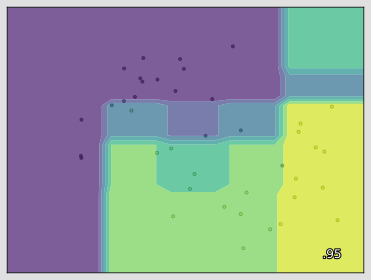

In [8]:
h = 0.2
ds = make_moons(noise=0.3, random_state=0)
X, y = ds
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
clf = createBNClassifier(
  learningMethod="MIIC",
  prior="Smoothing",
  priorWeight=0.01,
  discretizationNbBins=5,
  discretizationStrategy="kmeans",
  usePR=False,
)

clf.fit(X_train, y_train)
score = clf.score(X_test, y_test)

Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
clf.bn_

Z = Z.reshape(xx.shape)


ax = plt.subplot(1, 1, 1)

ax.set_xlim(xx.min(), xx.max())
ax.set_ylim(yy.min(), yy.max())
ax.set_xticks(())
ax.set_yticks(())

ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, alpha=0.6, edgecolors="k", marker=".")
ax.contourf(xx, yy, Z, alpha=0.7)

ax.text(
  xx.max() - 0.3,
  yy.min() + 0.3,
  ("%.2f" % score).lstrip("0"),
  size=12,
  horizontalalignment="right",
  color="white",
  path_effects=[pe.withStroke(linewidth=2, foreground="black")],
);

## n-ary classifiers on IRIS dataset

In [9]:
# From https://scikit-learn.org/stable/auto_examples/classification/plot_classification_probability.html#sphx-glr-auto-examples-classification-plot-classification-probability-py
# Author: Alexandre Gramfort <alexandre.gramfort@inria.fr>
# License: BSD 3 clause

Accuracy (train) for L1 logistic: 82.7% 
Accuracy (train) for L2 logistic (Multinomial): 82.7% 
Accuracy (train) for L2 logistic (OvR): 82.7% 
Accuracy (train) for Linear SVC: 82.0% 
Accuracy (train) for BN: 83.3% 


/Users/phw/.virtualenvs/devAgrum/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


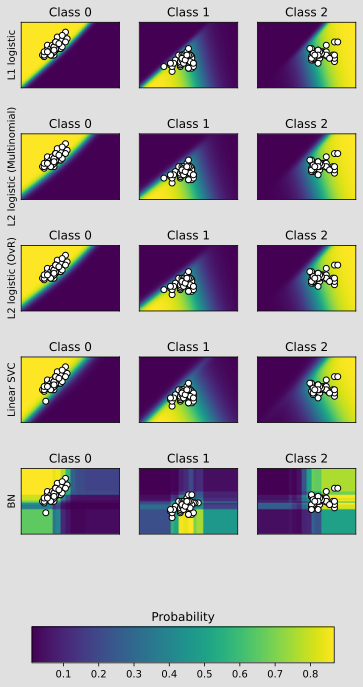

In [10]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data[:, 0:2]  # we only take the first two features for visualization
y = iris.target

n_features = X.shape[1]

C = 10
kernel = 1.0 * RBF([1.0, 1.0])  # for GPC

# Create different classifiers.
classifiers = {
  "L1 logistic": LogisticRegression(C=C, l1_ratio=1, solver="saga", max_iter=10000),
  "L2 logistic (Multinomial)": LogisticRegression(C=C, l1_ratio=0, solver="saga", max_iter=10000),
  "L2 logistic (OvR)": LogisticRegression(C=C, l1_ratio=0, solver="saga", max_iter=10000),
  "Linear SVC": SVC(kernel="linear", C=C, probability=True, random_state=0),
  # 'GPC': GaussianProcessClassifier(kernel), # too long
  "BN": createBNClassifier(
    learningMethod="MIIC",
    prior="Smoothing",
    priorWeight=1,
    discretizationNbBins=9,
    discretizationStrategy="quantile",
    discretizationThreshold=10,
  ),
}

n_classifiers = len(classifiers)

plt.figure(figsize=(3 * 2, n_classifiers * 2))
plt.subplots_adjust(bottom=0.2, top=0.95)

xx = np.linspace(3, 9, 100)
yy = np.linspace(1, 5, 100).T
xx, yy = np.meshgrid(xx, yy)
Xfull = np.c_[xx.ravel(), yy.ravel()]

for index, (name, classifier) in enumerate(classifiers.items()):
  classifier.fit(X, y)

  y_pred = classifier.predict(X)
  accuracy = accuracy_score(y, y_pred)
  print("Accuracy (train) for %s: %0.1f%% " % (name, accuracy * 100))

  # View probabilities:
  probas = classifier.predict_proba(Xfull)
  n_classes = np.unique(y_pred).size
  for k in range(n_classes):
    plt.subplot(n_classifiers, n_classes, index * n_classes + k + 1)
    plt.title("Class %d" % k)
    if k == 0:
      plt.ylabel(name)
    imshow_handle = plt.imshow(probas[:, k].reshape((100, 100)), extent=(3, 9, 1, 5), origin="lower")
    plt.xticks(())
    plt.yticks(())
    idx = y_pred == k
    if idx.any():
      plt.scatter(X[idx, 0], X[idx, 1], marker="o", c="w", edgecolor="k")

ax = plt.axes([0.15, 0.04, 0.7, 0.05])
plt.title("Probability")
plt.colorbar(imshow_handle, cax=ax, orientation="horizontal")

plt.show()

So the BNClassifier gives the 'best' accuracy (even if discretized). Moreover, once again, it propose a structural representation of the classification mechanism.

In [11]:
classifiers["BN"].bn_

(pyagrum.BayesNet@0x77e5f4000) BN{nodes: 3, arcs: 2, domainSize: 243, dim: 50, mem: 504o}

## Recognizing hand-written digits with Bayesian Networks 

In [12]:
# From https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html#sphx-glr-auto-examples-classification-plot-digits-classification-py
# Author: Gael Varoquaux <gael dot varoquaux at normalesup dot org>
# License: BSD 3 clause

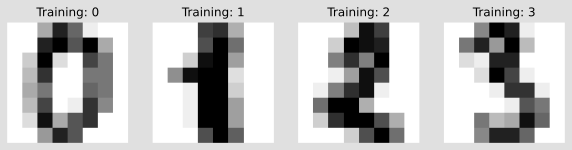

In [13]:
# Standard scientific Python imports
import matplotlib.pyplot as plt

# Import datasets, classifiers and performance metrics
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split

digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
  ax.set_axis_off()
  ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
  ax.set_title("Training: %i" % label)

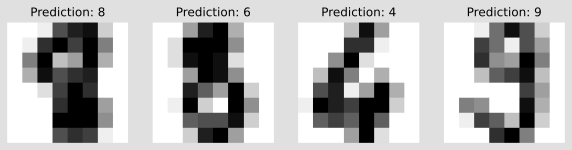

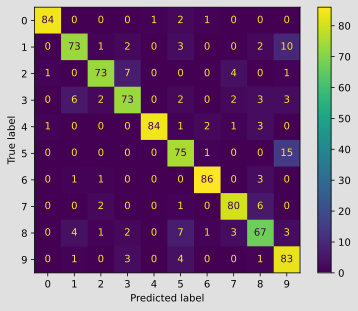

Classification report for classifier BNClassifier(prior='Smoothing',
             type_processor=<pyagrum.lib.discreteTypeProcessor.DiscreteTypeProcessor object at 0x118c7def0>):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        88
           1       0.86      0.80      0.83        91
           2       0.91      0.85      0.88        86
           3       0.84      0.80      0.82        91
           4       0.99      0.91      0.95        92
           5       0.79      0.82      0.81        91
           6       0.95      0.95      0.95        91
           7       0.89      0.90      0.89        89
           8       0.79      0.76      0.77        88
           9       0.72      0.90      0.80        92

    accuracy                           0.87       899
   macro avg       0.87      0.87      0.87       899
weighted avg       0.87      0.87      0.87       899




In [14]:
# flatten the images
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1)).astype(int)

# Create a classifier: a support vector classifier
# clf = svm.SVC(gamma=0.001)
clf = createBNClassifier(
  learningMethod="MIIC",
  prior="Smoothing",
  priorWeight=1,
  discretizationNbBins=3,
  discretizationStrategy="kmeans",
  discretizationThreshold=10,
)

# Split data into 50% train and 50% test subsets
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.5, shuffle=False)

# Learn the digits on the train subset
clf.fit(X_train, y_train)

# Predict the value of the digit on the test subset
predicted = clf.predict(X_test)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
  ax.set_axis_off()
  image = image.reshape(8, 8)
  ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
  ax.set_title(f"Prediction: {int(prediction)}")

cm = metrics.confusion_matrix(y_test, predicted)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

print(f"Classification report for classifier {clf}:\n{metrics.classification_report(y_test, predicted)}\n")

### Focus on the pixels needed for the classification

As always, using BNClassifier make us learn a bit more about the structure of the problem. 

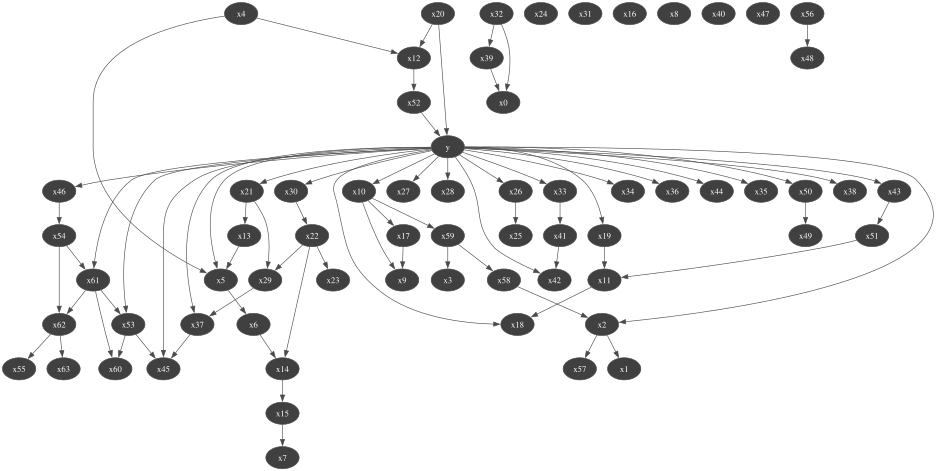

In [15]:
gnb.show(clf.bn_, size="13!")

Then, once again, the Markov Blanket gives us the relevant features (here the pixels)

Markov blanket of the classifier:


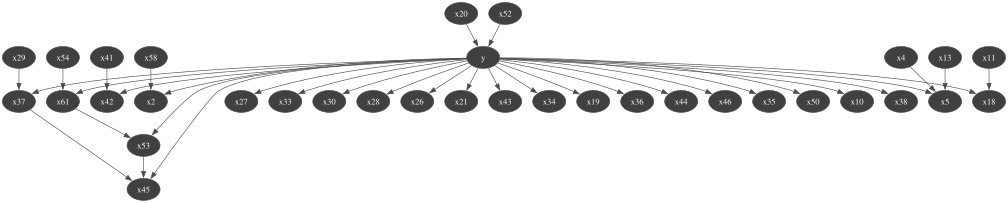

Number of pixels used for classification : 33/64


In [16]:
print("Markov blanket of the classifier:")
gnb.show(clf.MarkovBlanket_, size="14!")
print(f"Number of pixels used for classification : {clf.MarkovBlanket_.size() - 1}/64")

It appears that many pixels are not relevant for this classification.

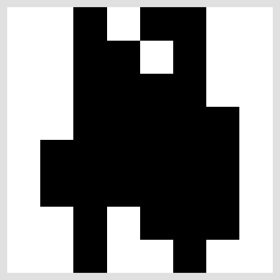

In [17]:
# Visualization of the pixels of the Markov Blanket

fig, ax = plt.subplots()
ax.set_axis_off()
relevant_pixels = set([int(x[1:]) for x in clf.MarkovBlanket_.names() if x != "y"])
ax.imshow(np.array([1 if i in relevant_pixels else 0 for i in range(64)]).reshape(8, 8), cmap=plt.cm.gray_r)
plt.show()